In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [3]:
from google.colab import files
uploaded = files.upload()

Saving adult.csv to adult.csv


In [4]:
import pandas as pd

data = pd.read_csv("adult.csv")
print(data.head())

   age  workclass  fnlwgt  education  education-num marital-status  \
0   39  State-gov   77516  Bachelors             13  Never-married   
1   50   Self-emp   83311  Bachelors             13        Married   
2   38    Private  215646    HS-grad              9       Divorced   
3   53    Private  234721       11th              7        Married   
4   28    Private  338409  Bachelors             13        Married   

        occupation   relationship   race     sex  capital-gain  capital-loss  \
0     Adm-clerical  Not-in-family  White    Male          2174             0   
1  Exec-managerial        Husband  White    Male             0             0   
2         Handlers  Not-in-family  White    Male             0             0   
3         Handlers        Husband  Black    Male             0             0   
4   Prof-specialty           Wife  Black  Female             0             0   

   hours-per-week native-country income  
0              40  United-States  <=50K  
1             

In [5]:
data = data.replace('?', np.nan)
data = data.dropna()

In [6]:
data['income'] = data['income'].map({'<=50K': 0, '>50K': 1})

In [7]:
data = pd.get_dummies(data)

In [8]:
X = data.drop("income", axis=1)
y = data["income"]


In [9]:
scaler = StandardScaler()
X = scaler.fit_transform(X)


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [11]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(X.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.6667 - loss: 0.8275 - val_accuracy: 0.0000e+00 - val_loss: 1.4621
Epoch 2/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.6667 - loss: 0.6658 - val_accuracy: 0.0000e+00 - val_loss: 1.4678
Epoch 3/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.6667 - loss: 0.7837 - val_accuracy: 0.0000e+00 - val_loss: 1.4740
Epoch 4/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.6667 - loss: 0.6303 - val_accuracy: 0.0000e+00 - val_loss: 1.4751
Epoch 5/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.6667 - loss: 0.6328 - val_accuracy: 0.0000e+00 - val_loss: 1.4743
Epoch 6/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.6667 - loss: 0.6909 - val_accuracy: 0.0000e+00 - val_loss: 1.4765
Epoch 7/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.6667 - loss: 0.6280 - val_accuracy: 0.0000e+00 - val_loss: 1.4786
Epoch 8/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.8333 - loss: 0.5387 - val_accuracy:

In [13]:
loss, accuracy = model.evaluate(X_test, y_test)
print("\nTest Accuracy:", accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.5000 - loss: 0.6625

Test Accuracy: 0.5


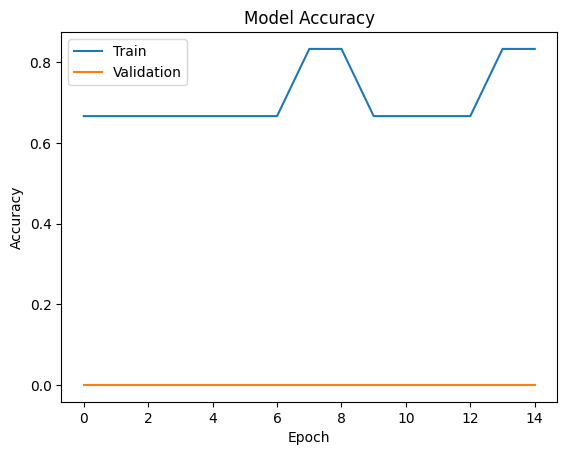

In [14]:
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()


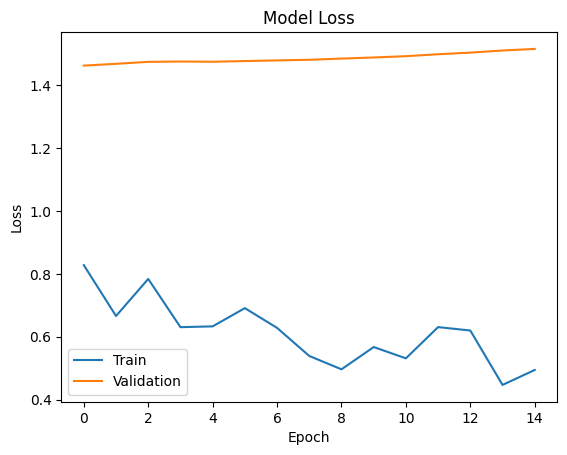

In [15]:
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])
plt.show()

EXPERIMENT 2: CNN for Image Classification

In [17]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [18]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training shape: (60000, 28, 28)
Testing shape: (10000, 28, 28)


In [19]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [20]:
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

In [22]:
model = models.Sequential()

# Convolution Layer 1
model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))
model.add(layers.MaxPooling2D(2,2))

# Convolution Layer 2
model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D(2,2))

# Flatten
model.add(layers.Flatten())

# Fully Connected Layers
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dropout(0.3))

# Output Layer
model.add(layers.Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [23]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [24]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_val, y_val)
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 43s 27ms/step - accuracy: 0.7766 - loss: 0.6163 - val_accuracy: 0.8570 - val_loss: 0.4008
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 46s 31ms/step - accuracy: 0.8504 - loss: 0.4144 - val_accuracy: 0.8790 - val_loss: 0.3288
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 42s 28ms/step - accuracy: 0.8698 - loss: 0.3587 - val_accuracy: 0.8828 - val_loss: 0.3171
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 84s 29ms/step - accuracy: 0.8836 - loss: 0.3242 - val_accuracy: 0.8918 - val_loss: 0.2862
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 79s 27ms/step - accuracy: 0.8919 - loss: 0.2954 - val_accuracy: 0.9016 - val_loss: 0.2728
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 41s 27ms/step - accuracy: 0.8984 - loss: 0.2762 - val_accuracy: 0.9043 - val_loss: 0.2595
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 41s 27ms/step - accuracy: 0.9055 - loss: 0.2582 - val_accuracy: 0.9044 - val_loss: 0.2575
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 42s 28ms/step - accuracy: 0.9114 -

In [25]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9041 - loss: 0.2715
Test Accuracy: 0.9041000008583069


In [26]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step


In [27]:
print(classification_report(y_test, y_pred_classes))

              precision    recall  f1-score   support

           0       0.86      0.85      0.85      1000
           1       1.00      0.98      0.99      1000
           2       0.84      0.86      0.85      1000
           3       0.91      0.91      0.91      1000
           4       0.86      0.84      0.85      1000
           5       0.99      0.97      0.98      1000
           6       0.71      0.73      0.72      1000
           7       0.93      0.98      0.96      1000
           8       0.98      0.98      0.98      1000
           9       0.99      0.94      0.96      1000

    accuracy                           0.90     10000
   macro avg       0.91      0.90      0.90     10000
weighted avg       0.91      0.90      0.90     10000



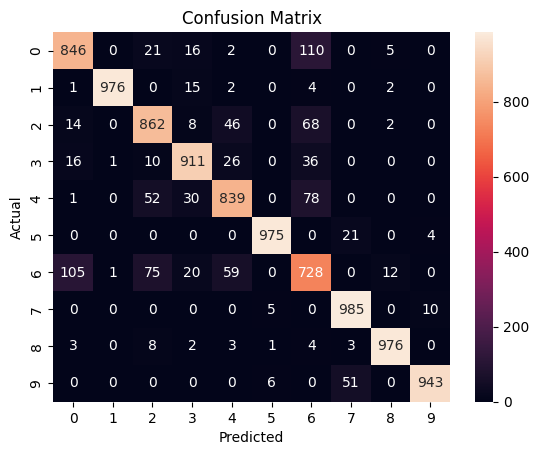

In [28]:
cm = confusion_matrix(y_test, y_pred_classes)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

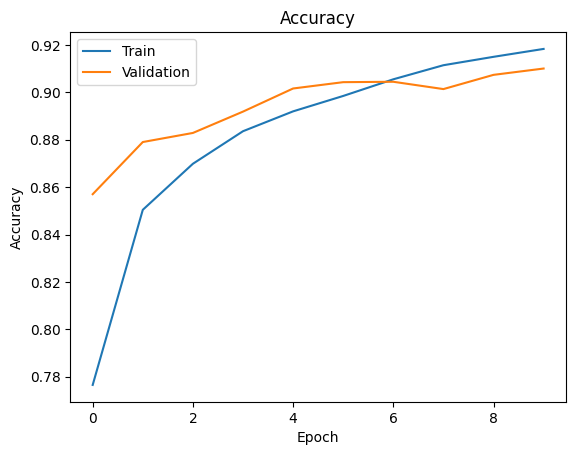

In [29]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

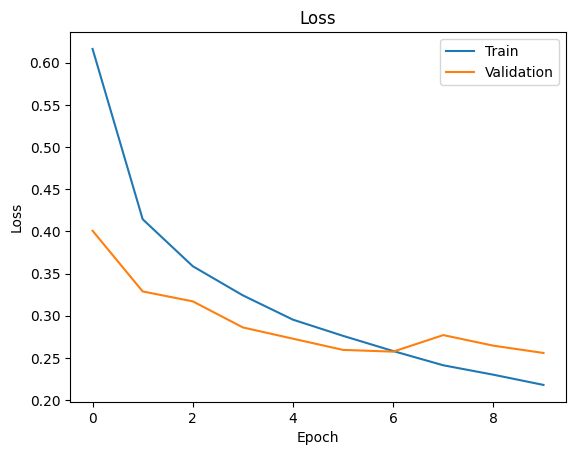

In [30]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])
plt.show()

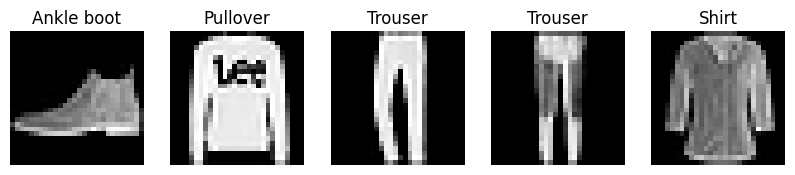

In [31]:
class_names = ["T-shirt", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

plt.figure(figsize=(10,5))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(X_test[i].reshape(28,28), cmap='gray')
    plt.title(class_names[y_pred_classes[i]])
    plt.axis('off')

plt.show()

Experiment 3: LSTM for Sequence Modeling

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

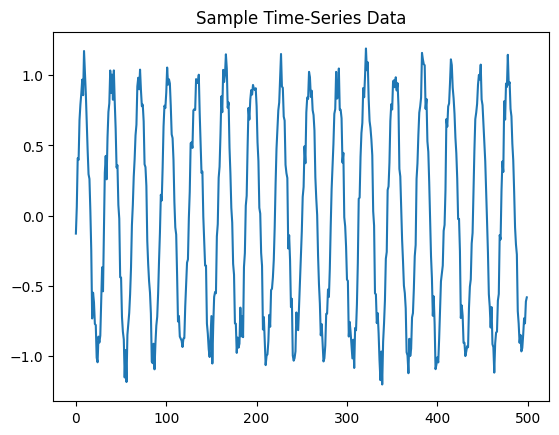

In [33]:
# Create dummy stock price data
data = pd.DataFrame({
    "price": np.sin(np.linspace(0, 100, 500)) + np.random.normal(0, 0.1, 500)
})

plt.plot(data["price"])
plt.title("Sample Time-Series Data")
plt.show()

In [34]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

In [35]:
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(seq_length, len(data)):
        X.append(data[i-seq_length:i])
        y.append(data[i])
    return np.array(X), np.array(y)

seq_length = 20
X, y = create_sequences(scaled_data, seq_length)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (480, 20, 1)
y shape: (480, 1)


In [36]:
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [37]:
model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(X.shape[1], 1)),
    LSTM(50),
    Dense(1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [38]:
model.compile(
    optimizer='adam',
    loss='mse'
)

In [39]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 114ms/step - loss: 0.1713 - val_loss: 0.1028
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0901 - val_loss: 0.0685
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0542 - val_loss: 0.0316
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0194 - val_loss: 0.0061
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0048 - val_loss: 0.0032
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0036 - val_loss: 0.0018
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0024 - val_loss: 0.0016
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0023 - val_loss: 0.0015
Epoch 9/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0024 - val_loss: 0.0018
Epoch 10/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0022 - val_loss: 0.0015


In [40]:
loss = model.evaluate(X_test, y_test)
print("Test Loss (MSE):", loss)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0015
Test Loss (MSE): 0.0014993947697803378


In [41]:
predictions = model.predict(X_test)

# Convert back to original scale
predictions = scaler.inverse_transform(predictions)
y_test_actual = scaler.inverse_transform(y_test)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step 


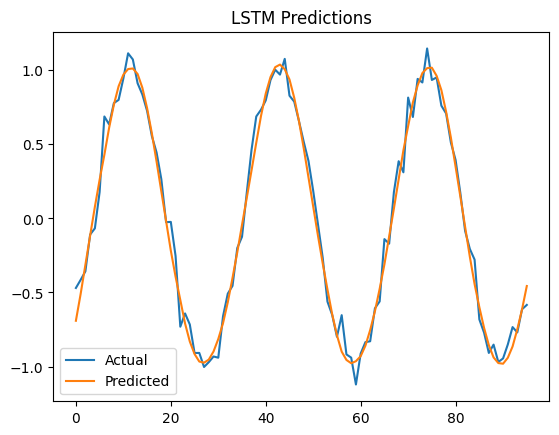

In [42]:
plt.plot(y_test_actual, label="Actual")
plt.plot(predictions, label="Predicted")
plt.title("LSTM Predictions")
plt.legend()
plt.show()

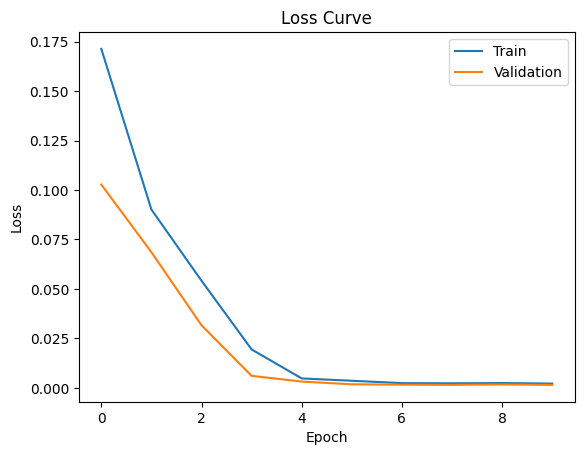

In [43]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])
plt.show()